<a href="https://colab.research.google.com/gist/simsim-px/5ee21b23108fae61da3aba4565dcc464/mp5-franck-hertz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import pandas as pd
from google.colab import files
from IPython.display import display, HTML

# Upload file
uploaded = files.upload()

# Baca file Excel
file_name = next(iter(uploaded))
df = pd.read_excel(file_name, skiprows=2)

# Ambil dua kolom: Variasi 220 dan 130
variasi_220 = df.iloc[:, [0, 1]].copy()
variasi_130 = df.iloc[:, [2, 3]].copy()

# Ganti nama kolom
variasi_220.columns = ['Tegangan 220 (V)', 'Arus 220 (nA)']
variasi_130.columns = ['Tegangan 130 (V)', 'Arus 130 (nA)']

# Hapus baris kosong
variasi_130 = variasi_130.dropna(how='all').reset_index(drop=True)

# Gabungkan tabel
gabung = pd.concat([variasi_220, variasi_130], axis=1)

# Tampilkan tabel
display(HTML(gabung.to_html(index=False)))

Saving DATA ANALISIS MP5.xlsx to DATA ANALISIS MP5.xlsx


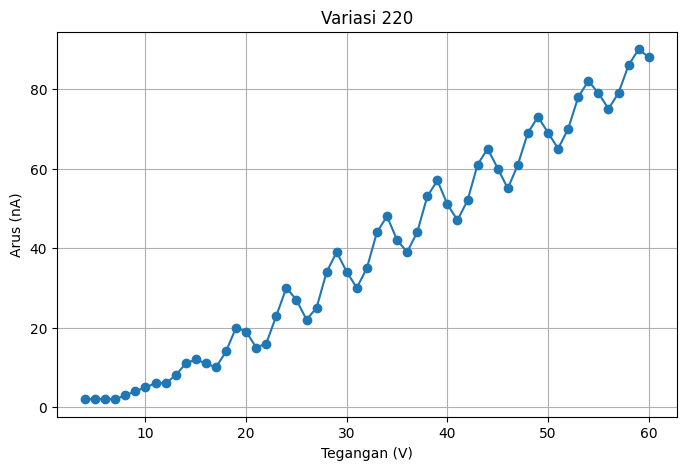

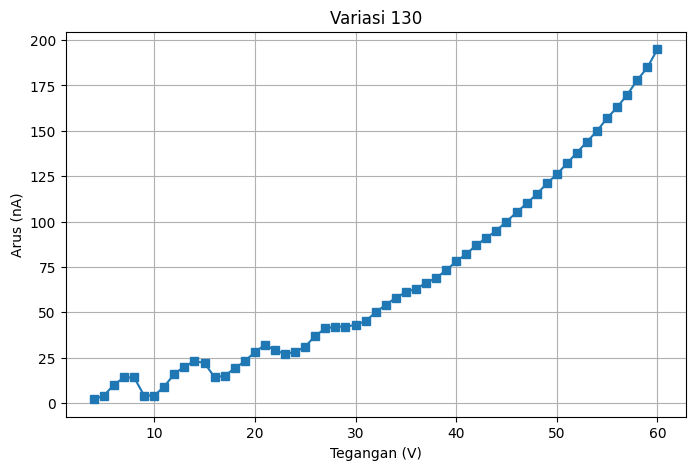

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
data = pd.read_excel(file_name, skiprows=4)

data_cleaned = data.iloc[:, [0, 1, 2, 3]]
data_cleaned.columns = ['V_220', 'I_220', 'V_130', 'I_130']

# Grafik Variasi 230
plt.figure(figsize=(8,5))
plt.plot(data_cleaned['V_220'], data_cleaned['I_220'], marker='o')
plt.title('Variasi 220')
plt.xlabel('Tegangan (V)')
plt.ylabel('Arus (nA)')
plt.grid(True)
plt.show()

# Grafik Variasi 130
plt.figure(figsize=(8,5))
plt.plot(data_cleaned['V_130'], data_cleaned['I_130'], marker='s')
plt.title('Variasi 130')
plt.xlabel('Tegangan (V)')
plt.ylabel('Arus (nA)')
plt.grid(True)
plt.show()

Saving DATA ANALISIS MP5.xlsx to DATA ANALISIS MP5 (2).xlsx


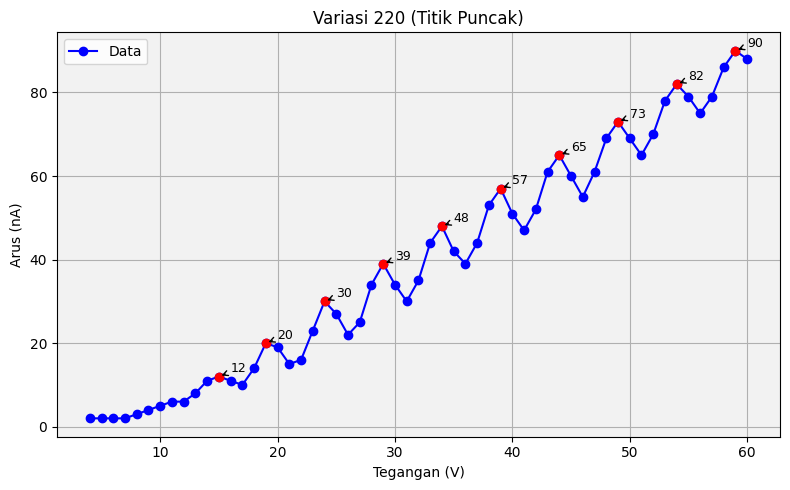

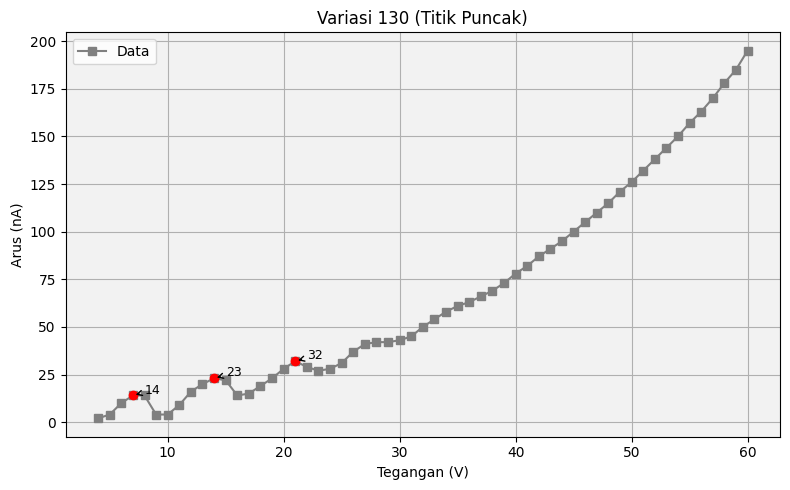

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
data = pd.read_excel(file_name, skiprows=4)

data_cleaned = data.iloc[:, [0,1,2,3]].copy()
data_cleaned.columns = ['V_220', 'I_220', 'V_130', 'I_130']

data_cleaned = data_cleaned.dropna().reset_index(drop=True)

# Fungsi plotting dengan titik puncak
def plot_with_local_peaks(voltage, current, title, color, marker, save_name):

    voltage = pd.to_numeric(voltage)
    current = pd.to_numeric(current)

    plt.figure(figsize=(8,5))
    plt.plot(voltage, current, marker=marker, color=color, label='Data')

    plt.title(title)
    plt.xlabel('Tegangan (V)')
    plt.ylabel('Arus (nA)')
    plt.grid(True)
    plt.gca().set_facecolor('#f2f2f2')

    # Cari titik puncak
    peaks, _ = find_peaks(current)

    for idx in peaks:
        v = voltage.iloc[idx]
        i = current.iloc[idx]

        plt.scatter(v, i, color='red', zorder=3)

        plt.annotate(f'{i}',
                     xy=(v, i),
                     xytext=(v+1, i+1),
                     fontsize=9,
                     arrowprops=dict(arrowstyle='->'))

    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_name}.png", dpi=300)
    plt.show()


# Plot grafik
plot_with_local_peaks(
    data_cleaned['V_220'],
    data_cleaned['I_220'],
    'Variasi 220 (Titik Puncak)',
    'blue',
    'o',
    'variasi_220_puncak'
)

plot_with_local_peaks(
    data_cleaned['V_130'],
    data_cleaned['I_130'],
    'Variasi 130 (Titik Puncak)',
    'gray',
    's',
    'variasi_130_puncak'
)

Saving DATA ANALISIS MP5.xlsx to DATA ANALISIS MP5 (3).xlsx


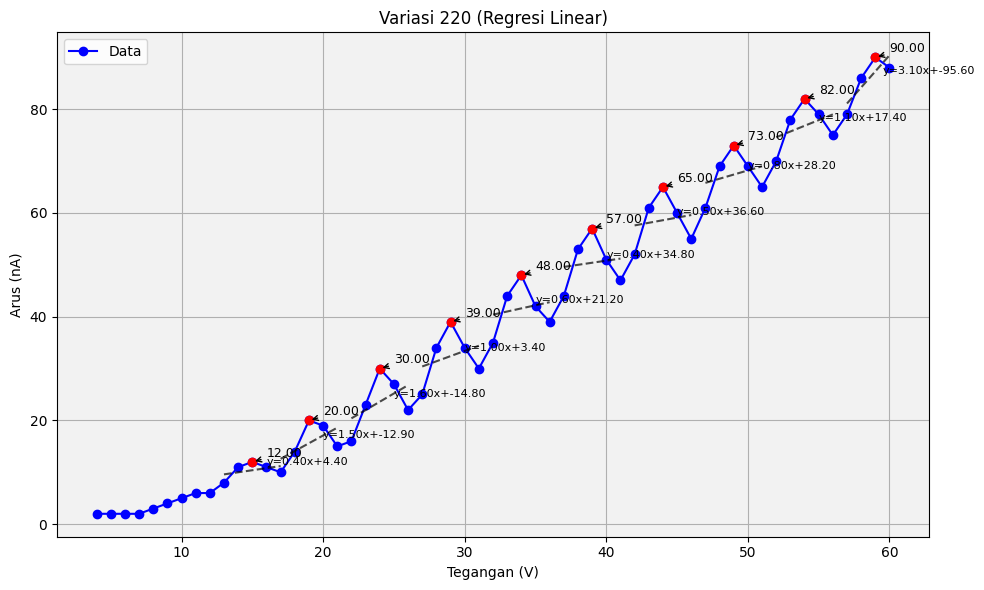

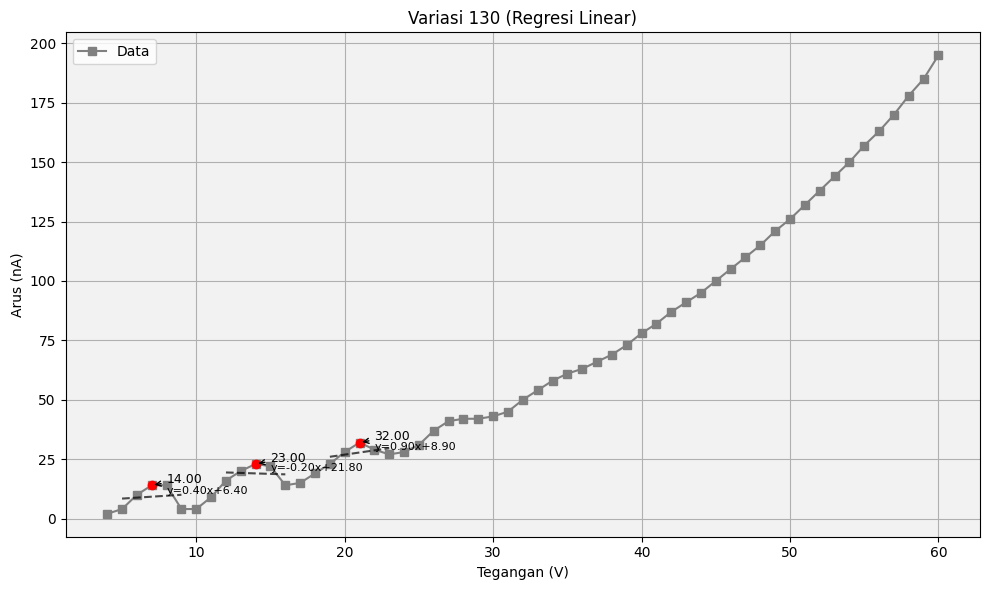

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import linregress
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))
data = pd.read_excel(file_name, skiprows=4)

data_cleaned = data.iloc[:, [0,1,2,3]].copy()
data_cleaned.columns = ['V_220', 'I_220', 'V_130', 'I_130']

data_cleaned = data_cleaned.dropna().reset_index(drop=True)

# Fungsi plotting
def plot_with_local_peaks_and_regression(voltage, current, title, color, marker, save_name, window=2):

    voltage = pd.to_numeric(voltage)
    current = pd.to_numeric(current)

    plt.figure(figsize=(10,6))
    plt.plot(voltage, current, marker=marker, color=color, label='Data')

    plt.title(title)
    plt.xlabel('Tegangan (V)')
    plt.ylabel('Arus (nA)')
    plt.grid(True)
    plt.gca().set_facecolor('#f2f2f2')

    peaks, _ = find_peaks(current)

    for idx in peaks:

        v_peak = voltage.iloc[idx]
        i_peak = current.iloc[idx]

        plt.scatter(v_peak, i_peak, color='red', zorder=3)

        plt.annotate(f'{i_peak:.2f}',
                     xy=(v_peak, i_peak),
                     xytext=(v_peak+1, i_peak+1),
                     fontsize=9,
                     arrowprops=dict(arrowstyle='->'))

        # Ambil data sekitar puncak
        start = max(0, idx-window)
        end = min(len(voltage), idx+window+1)

        local_v = voltage.iloc[start:end]
        local_i = current.iloc[start:end]

        if len(local_v) >= 2:

            slope, intercept, r_value, p_value, std_err = linregress(local_v, local_i)

            reg_line = slope*local_v + intercept
            plt.plot(local_v, reg_line, 'k--', alpha=0.7)

            x_mid = local_v.mean()
            y_mid = slope*x_mid + intercept

            plt.annotate(f'y={slope:.2f}x+{intercept:.2f}',
                         xy=(x_mid, y_mid),
                         xytext=(x_mid+1, y_mid+1),
                         fontsize=8)

    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_name}.png", dpi=300)
    plt.show()


# Plot grafik
plot_with_local_peaks_and_regression(
    data_cleaned['V_220'],
    data_cleaned['I_220'],
    'Variasi 220 (Regresi Linear)',
    'blue',
    'o',
    'variasi_220_puncak_regresi'
)

plot_with_local_peaks_and_regression(
    data_cleaned['V_130'],
    data_cleaned['I_130'],
    'Variasi 130 (Regresi Linear)',
    'gray',
    's',
    'variasi_130_puncak_regresi'
)

In [ ]:
!pip install qrcode[pil]  # Install library qrcode
import qrcode

# Masukkan link Google Colab
colab_link = "https://colab.research.google.com/gist/simsim-px/5ee21b23108fae61da3aba4565dcc464/mp5-franck-hertz.ipynb"

# Buat QR code
qr = qrcode.make(colab_link)

# Simpan QR code sebagai gambar
qr.save("colab_qr.png")

# Tampilkan QR code
from IPython.display import display
display(qr)